# Fragility Analysis on MDOF System

## Introduction

This notebook demonstrates how to derive and compare seismic fragility functions from pre-computed Modified Cloud Analysis (MCA) results. All fragility fitting methods available in OQ-VMTK are applied to the same dataset, covering lognormal CDF variants, generalised linear models, and an ordinal classifier, and their downstream effect on mean vulnerability functions is illustrated.

## References

[1] Lallemant, D., Kiremidjian, A., and Burton, H. (2015). Statistical procedures for developing earthquake damage fragility curves. *Earthquake Engineering & Structural Dynamics*, 44, 1373–1389.

## Initialize Libraries ##

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openquake.vmtk.postprocessor import postprocessor
from openquake.vmtk.plotter import plotter
from openquake.vmtk.utilities import import_from_pkl

## Import Pre-Computed Analysis Data ##

In [2]:
# Define the directory of the ground-motion and cloud analysis dictionaries
input_directory = './in'

# Import the intensity measure dictionary
ims = import_from_pkl(os.path.join(input_directory, 'imls_esrm20.pkl'))

# Import the analysis dictionary
ansys_dict = import_from_pkl(os.path.join(input_directory, 'ansys_out.pkl'))

## Define Analysis Parameters ##

In [3]:
# Intensity measures to use for postprocessing cloud analyses
IMTs = 'PGA'

# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds = [0.00150, 0.00545, 0.00952, 0.0135]

# The lower limit to be applied for censoring edp values (below 0.1 the
# minimum threshold for slight damage is considered a negligible case)
lower_limit = 0.1 * damage_thresholds[0]

# The upper limit to be applied for consoring edp values (above 1.5 the
# maximum threshold is considered a collapse case)
censored_limit = 1.5 * damage_thresholds[-1]

## Fragility Method Overview ##

Eight fragility fitting methods are available through `process_mca_results`. Methods 1–4 assume a lognormal demand distribution and differ only in how uncertainty is budgeted; Methods 5–7 are data-driven and make no distributional assumption on the EDP; Method 8 replaces bootstrap resampling with Bayesian MCMC to produce posterior confidence bands.

| # | `fragility_method` | Key extra parameters | Feature |
|---|---|---|---|
| 1 | `'lognormal'` | `sigma_build2build=0.0`, `sigma_ds=0.0` | Record-to-record uncertainty only |
| 2 | `'lognormal'` | `sigma_build2build=0.3`, `sigma_ds=0.0` | Adds building-to-building variability |
| 3 | `'lognormal'` | `sigma_build2build=0.3`, `sigma_ds=0.3` | Adds damage-state threshold uncertainty |
| 4 | `'lognormal'` | `fragility_rotation=True`, `rotation_percentile=0.10` | Rotates curve about the 10th-percentile IM; prevents overestimation at low shaking |
| 5 | `'logit'` | — | GLM with logit link; binary exceedance classification |
| 6 | `'probit'` | — | GLM with probit link; equivalent to lognormal MLE on binary data |
| 7 | `'ordinal'` | — | Ordinal CLM; fits all damage states jointly, enforcing non-crossing curves |
| 8 | `'lognormal'` | `cloud_method='classical'`, `n_mcmc=2000` | Bayesian MCMC; returns posterior confidence bands (Jalayer et al., 2015) |

As total dispersion grows (Methods 1→3), curves shift clockwise about the median — the left tail rises and the right tail flattens. Rotation (Method 4) anchors the curve at the 10th-percentile IM so that the added uncertainty does not inflate failure probabilities at low shaking levels, which would otherwise bias expected annual losses upward.

In [4]:
pp = postprocessor()
imls = ims['PGA']
edps = ansys_dict['max_peak_drift_list']

# Arguments shared by all methods
_kw = dict(lower_limit=lower_limit, censored_limit=censored_limit)

# Method 1: lognormal CDF — record-to-record uncertainty only
cloud_1 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  sigma_build2build=0.0, sigma_ds=0.0,
                                  fragility_method='lognormal', **_kw)

# Method 2: lognormal + building-to-building uncertainty
cloud_2 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  sigma_build2build=0.3, sigma_ds=0.0,
                                  fragility_method='lognormal', **_kw)

# Method 3: lognormal + building-to-building and damage-state uncertainty
cloud_3 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  sigma_build2build=0.3, sigma_ds=0.3,
                                  fragility_method='lognormal', **_kw)

# Method 4: lognormal + all uncertainties + rotation at 10th-percentile IM
cloud_4 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  sigma_build2build=0.3, sigma_ds=0.3,
                                  fragility_rotation=True, rotation_percentile=0.10,
                                  fragility_method='lognormal', **_kw)

# Method 5: GLM with logit link function
cloud_5 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  fragility_method='logit', **_kw)

# Method 6: GLM with probit link function
cloud_6 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  fragility_method='probit', **_kw)

# Method 7: ordinal CLM — fits all damage states simultaneously
cloud_7 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  fragility_method='ordinal', **_kw)

# Method 8: lognormal + Bayesian MCMC confidence bands (Jalayer et al. 2015)
cloud_8 = pp.process_mca_results(imls, edps, damage_thresholds,
                                  sigma_build2build=0.3, sigma_ds=0.3,
                                  fragility_method='lognormal',
                                  cloud_method='classical',
                                  n_mcmc=2000, n_mcmc_burnin=500, confidence_k=2,
                                  **_kw)

## Visualise Fragility Functions ##

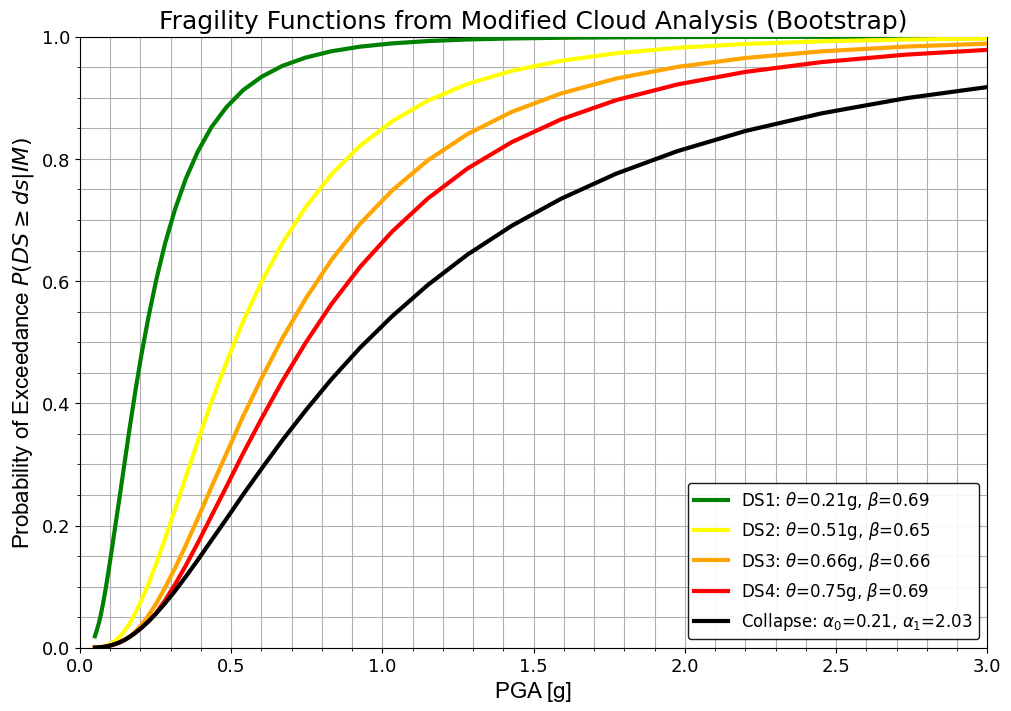

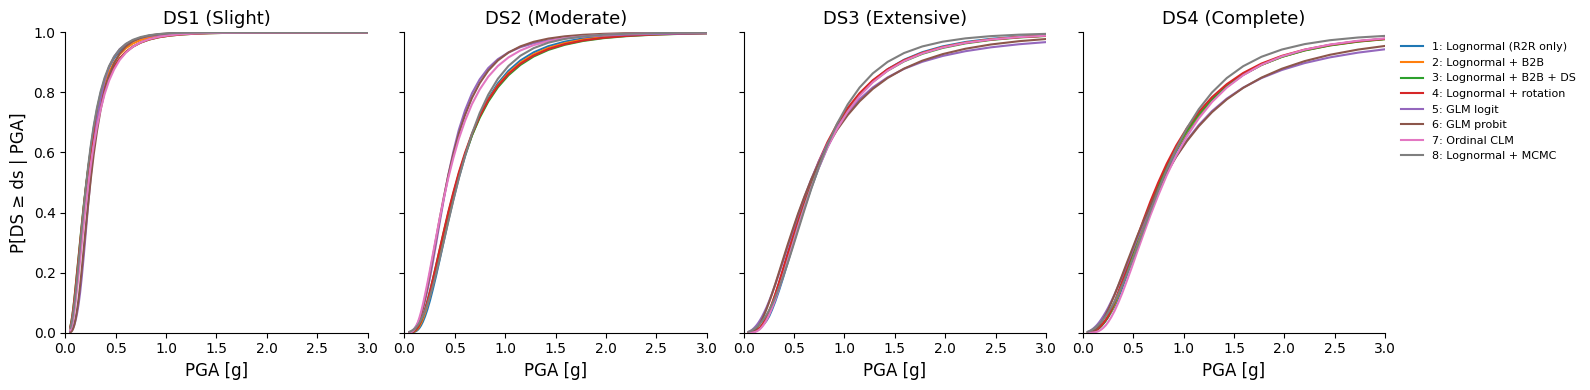

In [5]:
# Named method registry — used by both the fragility and vulnerability comparisons
METHODS = [
    ('1: Lognormal (R2R only)',  cloud_1),
    ('2: Lognormal + B2B',       cloud_2),
    ('3: Lognormal + B2B + DS',  cloud_3),
    ('4: Lognormal + rotation',  cloud_4),
    ('5: GLM logit',             cloud_5),
    ('6: GLM probit',            cloud_6),
    ('7: Ordinal CLM',           cloud_7),
    ('8: Lognormal + MCMC',      cloud_8),
]
DS_LABELS = ['DS1 (Slight)', 'DS2 (Moderate)', 'DS3 (Extensive)', 'DS4 (Complete)']

# Full fragility set for the recommended method (Method 4)
plt_cls = plotter()
plt_cls.plot_fragility_from_mca(
    cloud_4,
    imt_label='PGA [g]',
    xlims=[0, 3],
    ylims=[0, 1],
    export_path='out/fragility_method4.png',
)

# Four-panel comparison: all methods × all damage states
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, (ax, ds_label) in enumerate(zip(axes, DS_LABELS)):
    for label, cdict in METHODS:
        ax.plot(cdict['fragility']['intensities'],
                cdict['fragility']['poes'][:, i],
                label=label)
    ax.set_xlabel('PGA [g]', fontsize=12)
    ax.set_xlim([0, 3])
    ax.set_ylim([0, 1])
    ax.set_title(ds_label, fontsize=13)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('P[DS ≥ ds | PGA]', fontsize=12)
axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('out/fragility_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## Implication on Vulnerability Functions ##

In [6]:
# Consequence model: damage state → normalised loss ratio and its CoV
consequence_model = [0.05, 0.20, 0.60, 1.00]
consequence_cov   = [0.30, 0.25, 0.20, 0.00]

# Derive vulnerability function for every fragility method
vuln_results = {}
for label, cdict in METHODS:
    poes = cdict['fragility']['poes'][:, :4]
    vuln_results[label] = pp.calculate_vulnerability_function(
        poes, consequence_model, cov_consequence=consequence_cov, uncertainty=False
    )

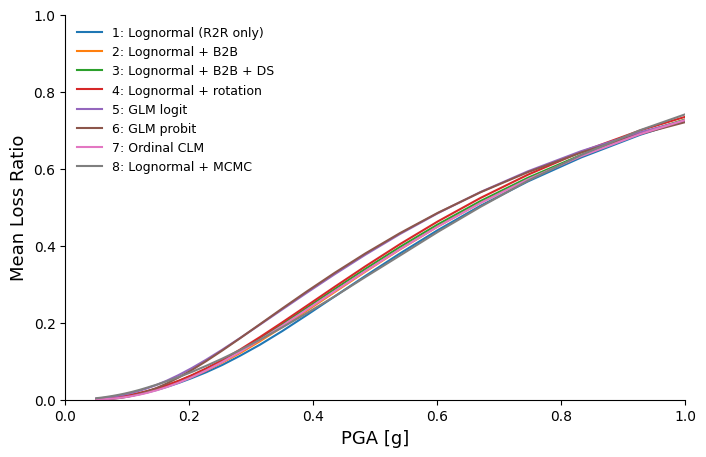

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, vdict in vuln_results.items():
    ax.plot(vdict['IML'], vdict['Loss'], label=label)

ax.set_xlabel('PGA [g]', fontsize=13)
ax.set_ylabel('Mean Loss Ratio', fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('out/vulnerability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## Average Annual Damage Probability by City ##

The Average Annual Damage Probability (AADP) integrates each fragility curve with the site hazard to give the annual rate at which a given damage state is expected to be exceeded. Comparing AADP across fragility methods reveals how the fitting choice propagates into risk — methods with higher total dispersion tend to produce a larger AADP at lower damage states (the raised left tail increases low-shaking contributions) but converge toward the same collapse probability at high-hazard sites dominated by large events. Six cities spanning a wide hazard range are used: Vancouver and Lisbon (low), Mexico City and Istanbul (medium), Wellington and Guatemala City (high).

AADP (%) — DS4 Complete Damage


,Vancouver,Lisbon,Mexico City,Istanbul,Wellington,Guatemala City
Method,,,,,,
1: Lognormal (R2R only),0.02207,0.02984,0.05680,0.36974,0.73359,0.87598
2: Lognormal + B2B,0.02340,0.03155,0.06006,0.38444,0.77112,0.91162
3: Lognormal + B2B + DS,0.02338,0.03166,0.06024,0.38859,0.77117,0.92012
4: Lognormal + rotation,0.02473,0.03333,0.06343,0.40316,0.81062,0.95607
5: GLM logit,0.05846,0.07430,0.14237,0.57608,1.48170,1.37862
6: GLM probit,0.03191,0.04125,0.07873,0.45057,1.00414,1.08659
7: Ordinal CLM,0.01355,0.02000,0.03776,0.30308,0.49305,0.70198
8: Lognormal + MCMC,0.05345,0.06877,0.13165,0.52774,1.30497,1.24668


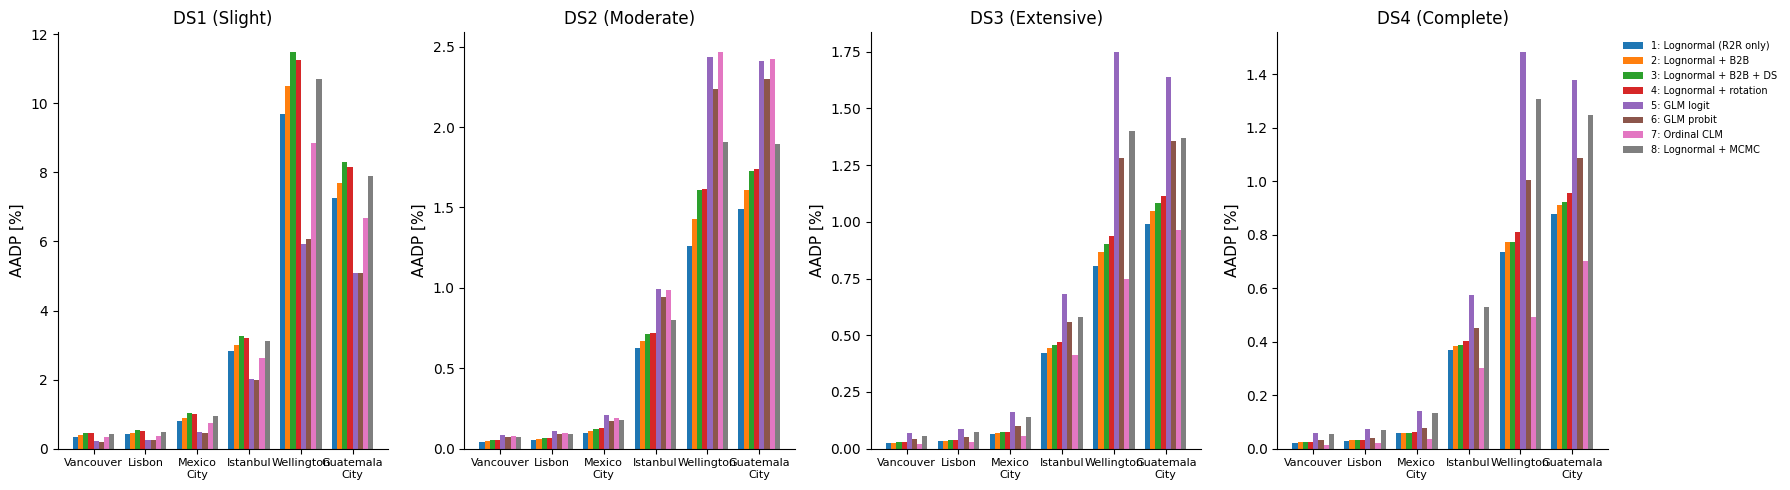

In [8]:
# Hazard curves: annual rate of exceedance vs PGA for 15 cities
hazard_in = pd.read_csv('./in/hazard_curves.csv')

# Six representative cities spanning a wide hazard range
selected_cities = ['Vancouver', 'Lisbon', 'Mexico City', 'Istanbul', 'Wellington', 'Guatemala City']

# Compute AADP for every method × every damage state × every city
aadp_data = {}
for label, cdict in METHODS:
    intensities = cdict['fragility']['intensities']
    poes_all = cdict['fragility']['poes']   # shape (n_iml, n_ds)
    method_data = {}
    for city in selected_cities:
        hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()
        ds_data = {}
        for ds_idx, ds_label in enumerate(DS_LABELS):
            frag_array = np.column_stack((intensities, poes_all[:, ds_idx]))
            aadp = pp.calculate_average_annual_damage_probability(
                fragility_array=frag_array,
                hazard_array=hazard_array,
                return_period=1.0,
                max_return_period=5000.0,
            )
            ds_data[ds_label] = aadp * 100  # %
        method_data[city] = ds_data
    aadp_data[label] = method_data

# Summary table: DS4 (complete damage) across all methods and cities
df_aadp_ds4 = pd.DataFrame(
    {label: {city: aadp_data[label][city]['DS4 (Complete)']
             for city in selected_cities}
     for label in aadp_data}
).T.round(5)
df_aadp_ds4.index.name = 'Method'
print("AADP (%) — DS4 Complete Damage")
display(df_aadp_ds4)

# Four-panel grouped bar chart: one subplot per damage state
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
x = np.arange(len(selected_cities))
width = 0.1
offsets = np.linspace(-3.5, 3.5, len(METHODS)) * width

for ds_idx, (ax, ds_label) in enumerate(zip(axes, DS_LABELS)):
    for (label, _), offset in zip(METHODS, offsets):
        values = [aadp_data[label][city][ds_label] for city in selected_cities]
        ax.bar(x + offset, values, width, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace(' ', '\n') for c in selected_cities], fontsize=8)
    ax.set_ylabel('AADP [%]', fontsize=11)
    ax.set_title(ds_label, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('out/aadp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## Average Annual Loss Ratio by City ##

The Average Annual Loss Ratio (AALR) integrates the vulnerability function with the site hazard to give expected loss per unit replacement value per year — the primary scalar used in insurance pricing and retrofit cost-benefit analysis. Because AALR is sensitive to the full shape of the vulnerability curve, small differences in fragility dispersion or method compound into systematic differences in risk. The comparison below shows how the choice of fragility fitting method translates directly into AALR spread across six cities spanning a wide hazard range.

,Vancouver,Lisbon,Mexico City,Istanbul,Wellington,Guatemala City
Method,,,,,,
1: Lognormal (R2R only),0.04189,0.05368,0.10268,0.55124,1.29081,1.33225
2: Lognormal + B2B,0.04636,0.05915,0.11321,0.58272,1.39446,1.40986
3: Lognormal + B2B + DS,0.05074,0.06455,0.12360,0.61018,1.48555,1.47614
4: Lognormal + rotation,0.05115,0.06507,0.12459,0.61847,1.50396,1.49679
5: GLM logit,0.07347,0.09260,0.17739,0.75408,1.95404,1.82358
6: GLM probit,0.05026,0.06331,0.12104,0.64577,1.55384,1.57765
7: Ordinal CLM,0.04242,0.05436,0.10391,0.56447,1.30849,1.36474
8: Lognormal + MCMC,0.07538,0.09523,0.18260,0.71927,1.90261,1.72630


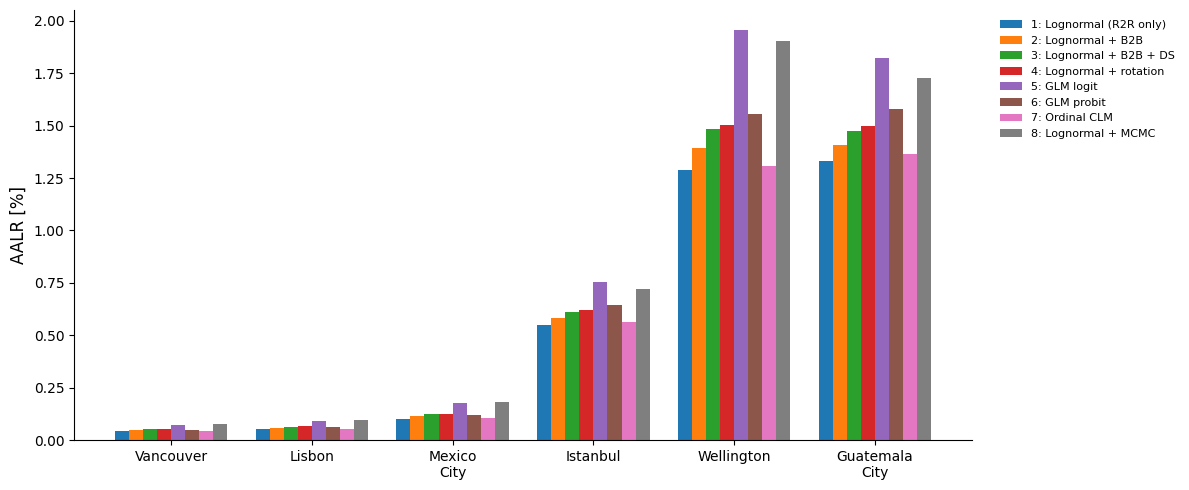

In [9]:
# Compute AALR for every method × every selected city
aalr_data = {}
for label, cdict in METHODS:
    vuln = vuln_results[label]
    vulnerability_array = vuln[['IML', 'Loss']].to_numpy()
    city_aalrs = {}
    for city in selected_cities:
        hazard_array = hazard_in.iloc[:, [0, hazard_in.columns.get_loc(city)]].to_numpy()
        aalr = pp.calculate_average_annual_loss(
            vulnerability_array=vulnerability_array,
            hazard_array=hazard_array,
            return_period=1.0,
            max_return_period=5000.0,
        )
        city_aalrs[city] = aalr * 100  # %
    aalr_data[label] = city_aalrs

# Summary table
df_aalr = pd.DataFrame(aalr_data).T.round(5)
df_aalr.index.name = 'Method'
display(df_aalr)

# Grouped bar chart — AALR by method and city
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(selected_cities))
width = 0.1
offsets = np.linspace(-3.5, 3.5, len(METHODS)) * width

for (label, _), offset in zip(METHODS, offsets):
    values = [aalr_data[label][city] for city in selected_cities]
    ax.bar(x + offset, values, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in selected_cities], fontsize=10)
ax.set_ylabel('AALR [%]', fontsize=12)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('out/aalr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)